In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as col
import Bayesian_Methods as Bayes
import Parameters as Pars
from Two_Par_Variation import TwoDimParVar

In [2]:
par1 = Pars.psi0
par2 = Pars.m0
ranges = dict([par1, par2])

In [30]:
#How do I organize the strains to pdfs?

In [31]:
np.min(hc_ss[0,0,0,:,:],axis=0) #minimum strain of frequency bin 0

NameError: name 'hc_ss' is not defined

In [32]:
hc_ss[0,0,7,33,:] #louder signal has lowest strain (must be small error from holodeck)

NameError: name 'hc_ss' is not defined

In [197]:
weakest_signals = []
for i in np.arange(40):
    v = np.where(hc_ss[0,0,i,:,:] == np.min(np.min(hc_ss[0,0,i,:,:],axis=0))) #weakest signal across all frequencies, realization number and loudest label
    weakest_signals.append(hc_ss[0,0,i,v[0][0],v[1][0]])

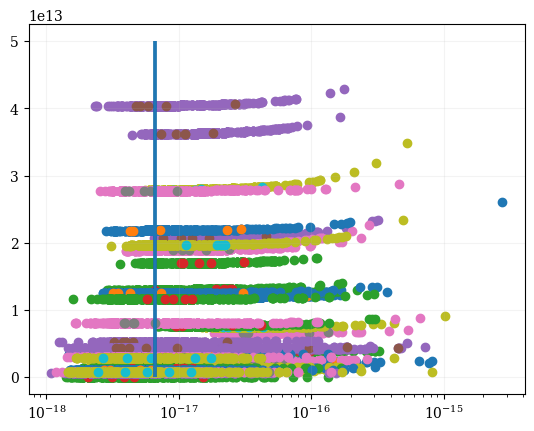

In [200]:
for i in np.arange(40):
    plt.scatter(hc_ss[0,0,i,:,:].ravel(),pdf[0,0,i,:,:].ravel())
    plt.scatter(hc_ss[0,0,i,0,:].ravel(),pdf[0,0,i,0,:].ravel()) #pdfs used together for realization 1 (Not corresponding strains)
   # plt.vlines(smalavg,ymin=0,ymax=5e13)
    plt.vlines(weakest_signal,ymin=0,ymax=5e13)
    #Maybe find 'average' strain position for a given frequency and use that as diagonalized (minimize square strain distance between each frequency strain pair and then average over this?)
    #Am I allowed to 'swap' realisations (I imagine I can for a given loudest smbhb) to get the best corresponding strains
    plt.xscale('log')
#plt.savefig('pdfs_to_strain_all_freqs')

In [3]:
locpdf = 'hc_PDF'
lochc = 'Data'
DistObj = Bayes.Distribution(ranges) #Initialize Distribution Object for the pre-defined parameters
PDF = DistObj.PDF(DistObj) #Create a pdf object from the given distribution object
pdf = PDF.load_pdf(locpdf) #Obtain the pdf distribution as an array
PDF.dim_names = np.array(('Frequencies', 'Realisations', 'Loudest')) #Set the name of the dimensions of the PDF to the dimensions of holodeck
Joinedpdf1 = DistObj.Joint_distribution(PDF) #Initialize a joint distribution object starting from a pre-existing distribution
FreqJoinedpdf = Joinedpdf1.joindiag('Frequencies') #pdf array + setting of joint distribution in Joinedpdf1 object (across frequencies)
Joinedpdf2 = DistObj.Joint_distribution(Joinedpdf1) #Initialize a joint distribution object starting from a pre-existing distribution
FreqLoudJoinedpdf = Joinedpdf2.joindiag('Loudest') #pdf array + setting of joint distribution in Joinedpdf1 object (across all loudest sources)

The pdf of the independent parameter hc_ss given the parameters ['psi0', 'm0'] has been set
Converting to log-space to avoid overflow


In [4]:
DistObjSing = Bayes.Distribution(ranges) #Initialize a new distribution object
PDFSing = DistObjSing.PDF(DistObjSing) #Create a pdf object from the given distribution object
pdfsingle = PDFSing.load_pdf(locpdf) #Obtain the pdf distribution as an array
PDFSing.dim_names = np.array(('Frequencies', 'Realisations', 'Loudest')) #Set the name of the dimensions of the PDF to the dimensions of holodeck
Joinedpdf3 = DistObjSing.Joint_distribution(PDFSing) #Initialize a joint distribution object starting from a pre-existing distribution
FreqJoinedpdfsing = Joinedpdf3.joindiag('Frequencies')
Joinedpdf4 = {f'loudest {i + 1} Frequency Joined PDF Object' : DistObjSing.Dimensional_Projection(Joinedpdf3) for i in np.arange(Joinedpdf3.dimensions[np.where(Joinedpdf3.dim_names == 'Loudest')[0][0]])}
FreqJoinedpdfsinglisted = [v.project('Loudest',i) for i,v in enumerate(list(Joinedpdf4.values()))]

The pdf of the independent parameter hc_ss given the parameters ['psi0', 'm0'] has been set
Converting to log-space to avoid overflow


In [5]:
DistObjSingFreq = Bayes.Distribution(ranges) #Initialize a new distribution object
PDFSingFreq = DistObjSingFreq.PDF(DistObjSingFreq) #Create a pdf object from the given distribution object
pdfsinglefreq = PDFSingFreq.load_pdf(locpdf) #Obtain the pdf distribution as an array
PDFSingFreq.dim_names = np.array(('Frequencies', 'Realisations', 'Loudest')) #Set the name of the dimensions of the PDF to the dimensions of holodeck
SingFreq = DistObjSingFreq.Dimensional_Projection(PDFSingFreq)
pdfsingfreq = SingFreq.project('Loudest', 0)
SingFreq2 = {f'Frequency {i + 1} loudest PDF Object' : DistObjSingFreq.Dimensional_Projection(SingFreq) for i in np.arange(SingFreq.dimensions[np.where(SingFreq.dim_names == 'Frequencies')[0][0]])}
pdfsingfreq2 = [v.project('Frequencies',i) for i,v in enumerate(list(SingFreq2.values()))]

The pdf of the independent parameter hc_ss given the parameters ['psi0', 'm0'] has been set


In [6]:
#Given that the prior is a uniform distribution that is constant, it just needs to be calculated
Priors = DistObj.Priors(DistObj) #Create a priors object from the given distribution object #Obtain the prior as an array (scalar)
PriorsLoudest = DistObj.Priors(DistObj) #Create a priors object from the given distribution object
PriorsLoudestSingFreq = DistObj.Priors(DistObj)
freqlen, reallen, loudlen = PDF.dimensions
U = Priors.Uniform()

FreqJoinedPriors = np.log10(U)*freqlen
FreqLoudJoinedPriors = FreqJoinedPriors*loudlen
FreqLoudestSing = np.log10(U)

Priors.distribution = FreqLoudJoinedPriors
Priors.log = True
PriorsLoudest.distribution = FreqJoinedPriors
PriorsLoudest.log = True
PriorsLoudestSingFreq.distribution = FreqLoudestSing
PriorsLoudestSingFreq.log = True

In [7]:
I = DistObj.MCI(Priors,Joinedpdf2)  
I.apply_prior()
Likelihoods = I.Integration('Realisations')

In [8]:
I2 = {f'loudest {i + 1} Frequency Joined Monte Carlo Integral Object' : DistObjSing.MCI(PriorsLoudest, v) for i,v in enumerate(list(Joinedpdf4.values()))}
for v in list(I2.values()):
    v.apply_prior()
Likelihoods2 = [v.Integration('Realisations') for v in list(I2.values())]

In [9]:
I3 = {f'Frequency bin {i} loudest MCI Object' : DistObjSingFreq.MCI(PriorsLoudestSingFreq, v) for i,v in enumerate(list(SingFreq2.values()))}
for v in list(I3.values()):
    v.apply_prior()
Likelihoods3 = [v.Integration('Realisations') for v in list(I3.values())]

In [12]:
np.shape(Likelihoods)
plt.plot(Likelihoods[0]

array([3.30516158e+120, 4.48150497e+120, 1.40369955e+121, 4.83503027e+122,
       8.91045865e+125, 4.25234146e+132, 1.51462885e+143, 7.56152754e+149,
       9.33688346e+141, 8.29331597e-017, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000])

In [ ]:
figs, ax = plt.subplots(layout='constrained')
figsize=(16,4)
im = ax.imshow(np.log10(Likelihoods), cmap='hot', interpolation='nearest',extent = (list(DistObj.parameters)[1][0],list(DistObj.parameters)[1][-1],list(DistObj.parameters)[0][-1],list(DistObj.parameters)[0][0]), aspect = 'auto')
ax.set_xlabel(DistObj.par_names[1],fontsize=16)
ax.set_ylabel(DistObj.par_names[0],fontsize=16)
figs.colorbar(im,label='Likelihood')

<Figure size 640x480 with 0 Axes>

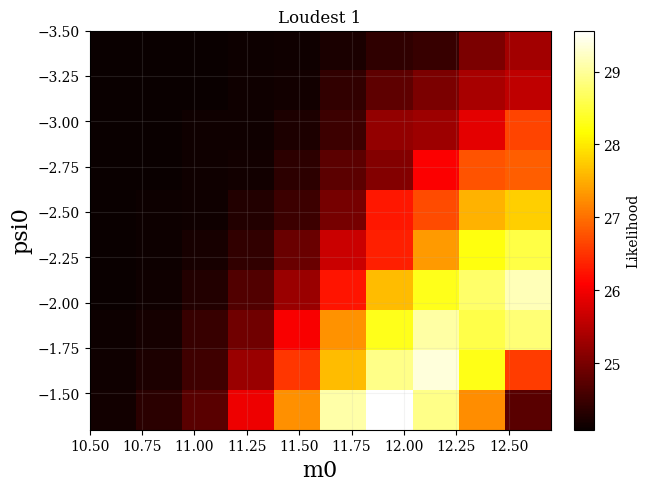

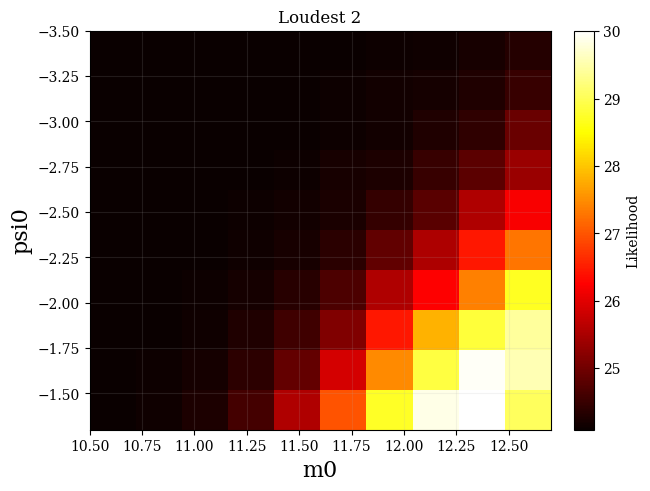

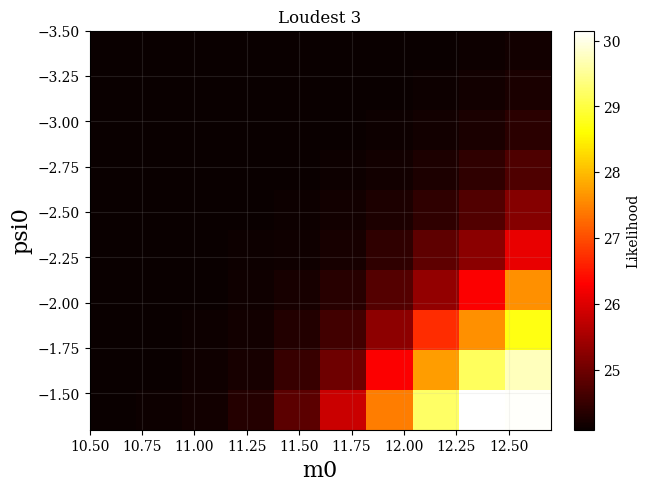

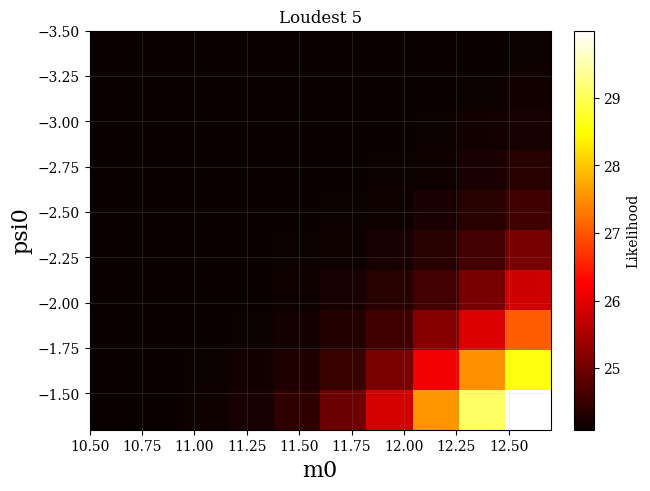

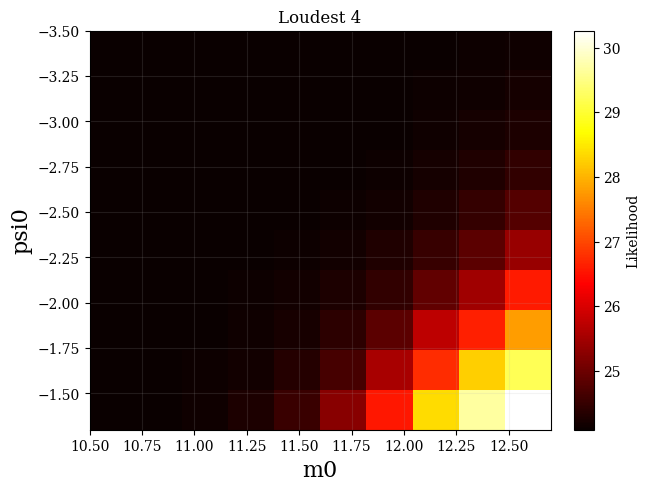

In [24]:
figsize=(16,4)
for i,v in enumerate(Likelihoods2):
    figs, ax = plt.subplots(layout='constrained')
    plt.title(f'Loudest {i+1}')
    plt.figure(i)
    im = ax.imshow(np.log10(v), cmap='hot', interpolation='nearest',extent = (list(DistObj.parameters)[1][0],list(DistObj.parameters)[1][-1],list(DistObj.parameters)[0][-1],list(DistObj.parameters)[0][0]), aspect = 'auto')
    ax.set_xlabel(DistObj.par_names[1],fontsize=16)
    ax.set_ylabel(DistObj.par_names[0],fontsize=16)
    figs.colorbar(im,label='Likelihood')

C:\Users\pxt561\AppData\Local\Temp\ipykernel_22348\4018850843.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figs, ax = plt.subplots(layout='constrained')


<Figure size 640x480 with 0 Axes>

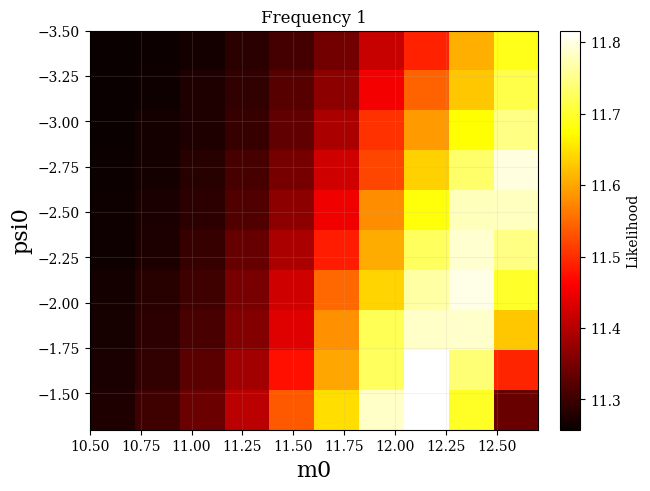

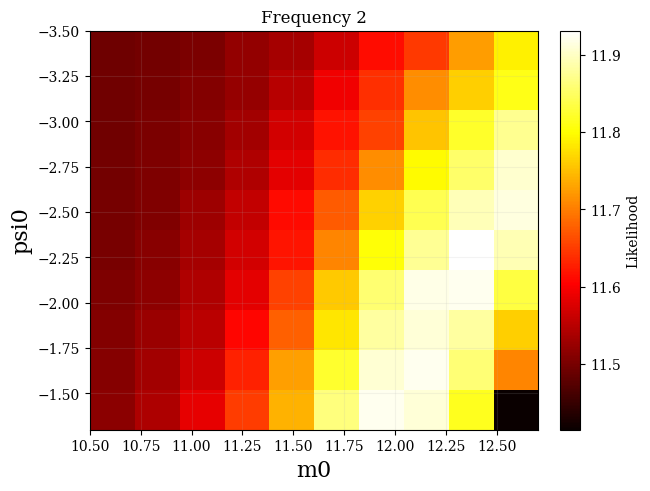

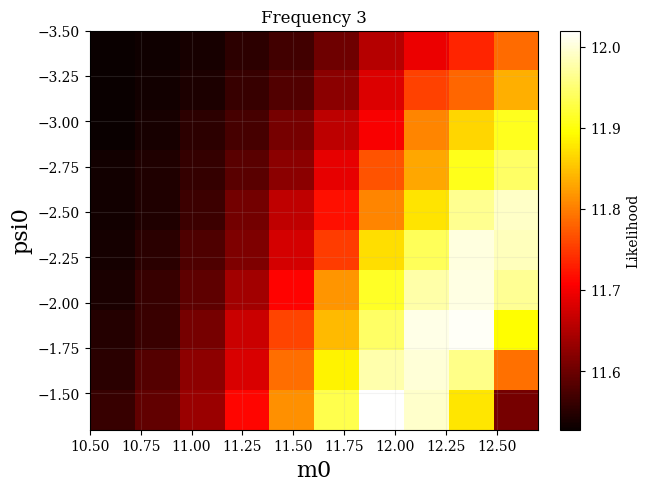

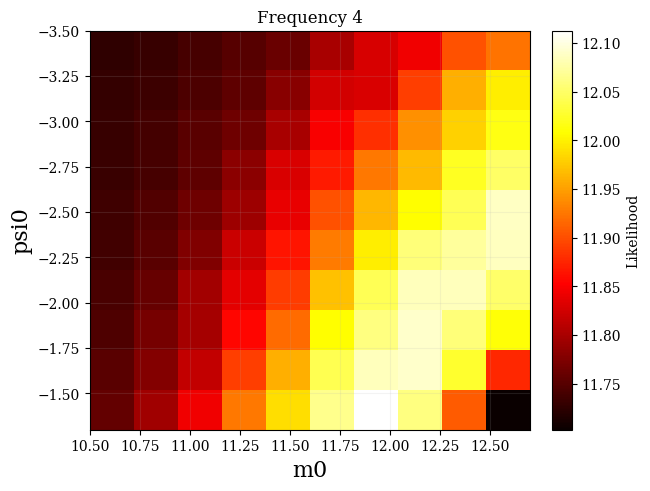

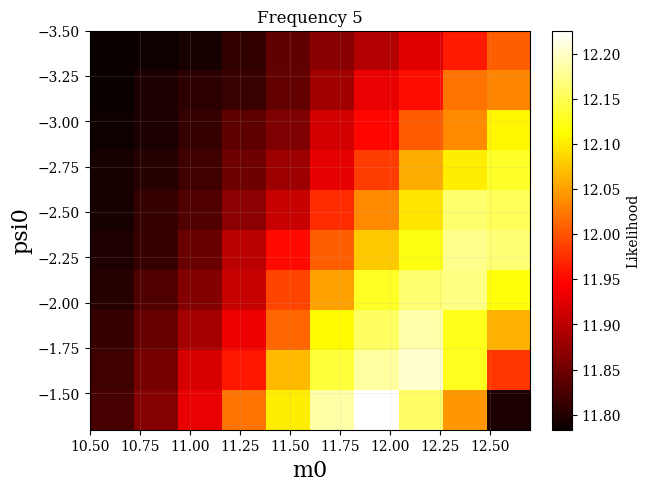

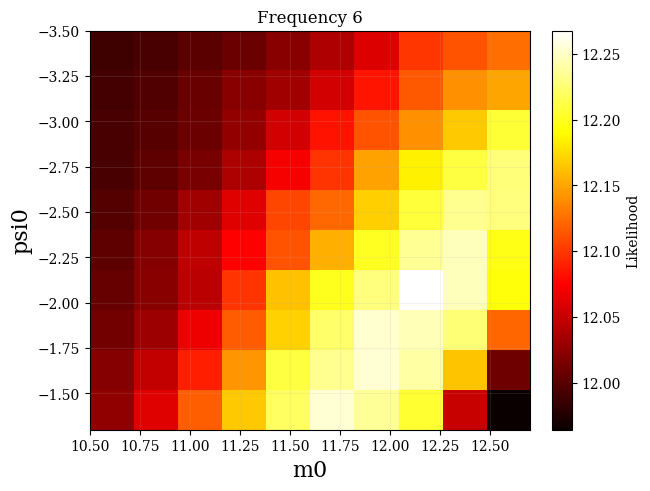

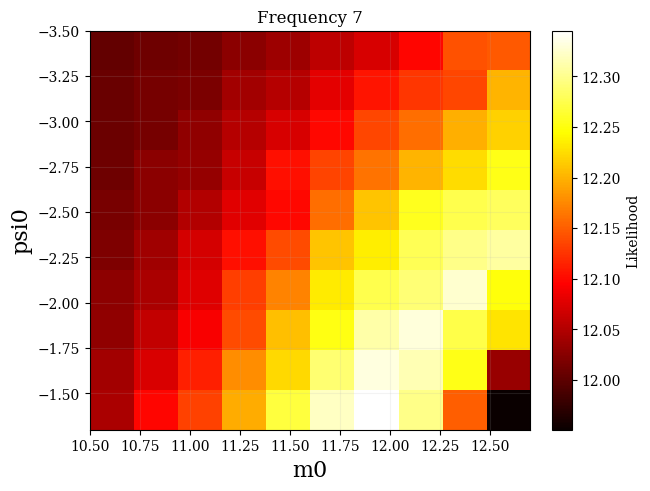

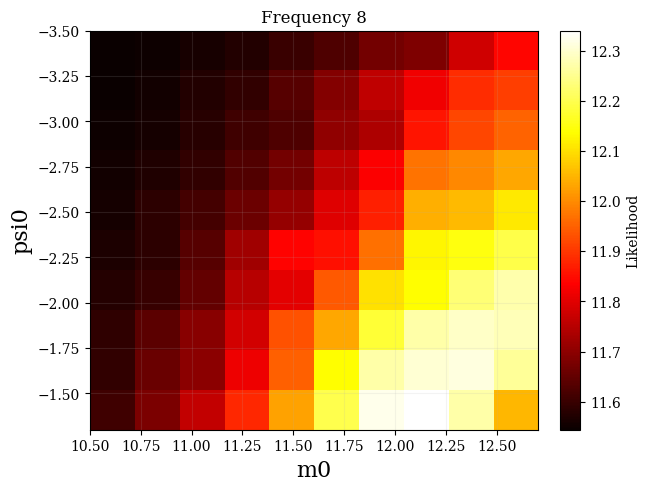

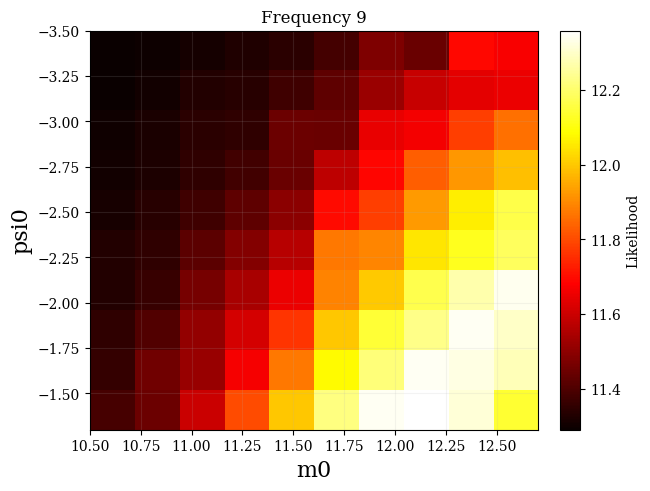

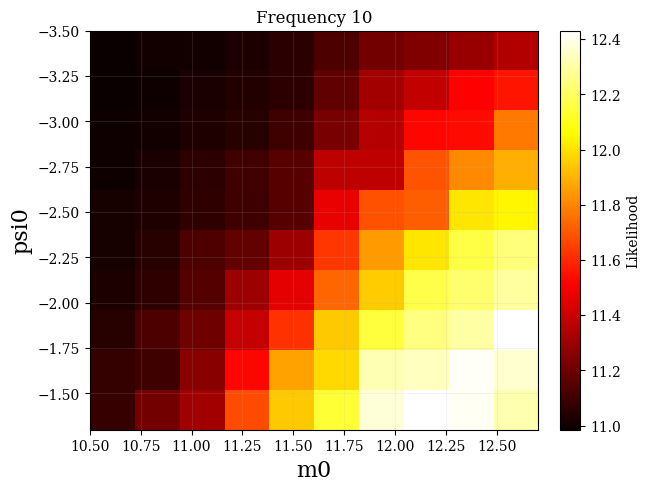

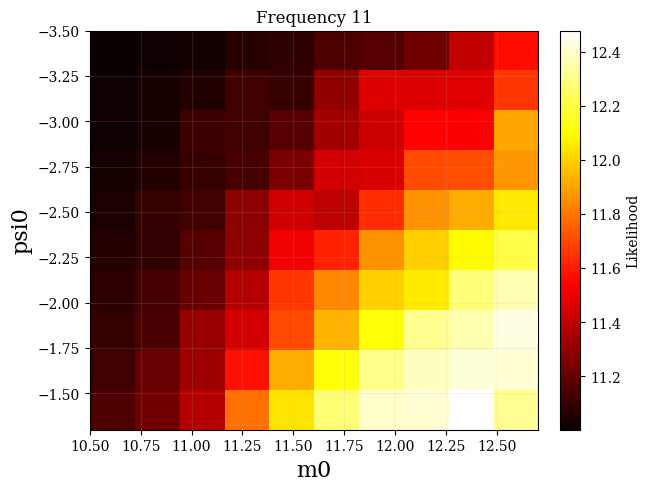

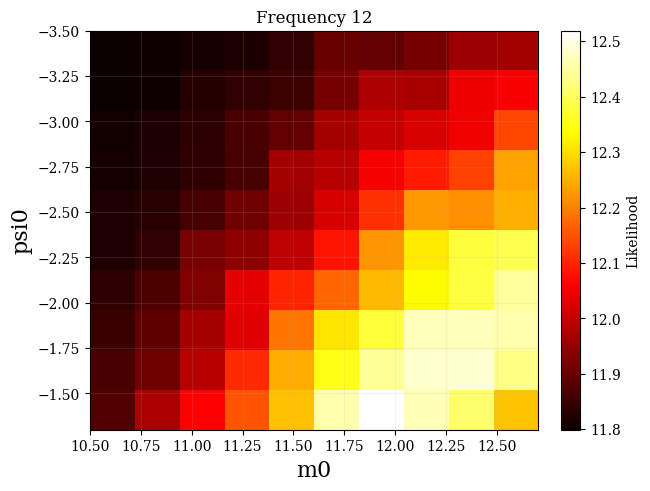

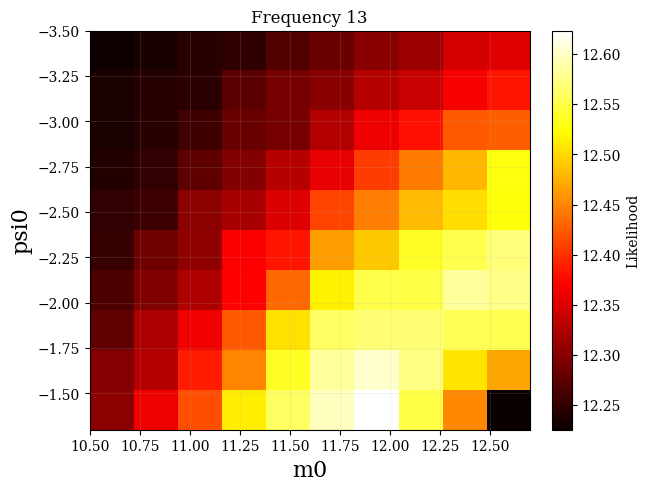

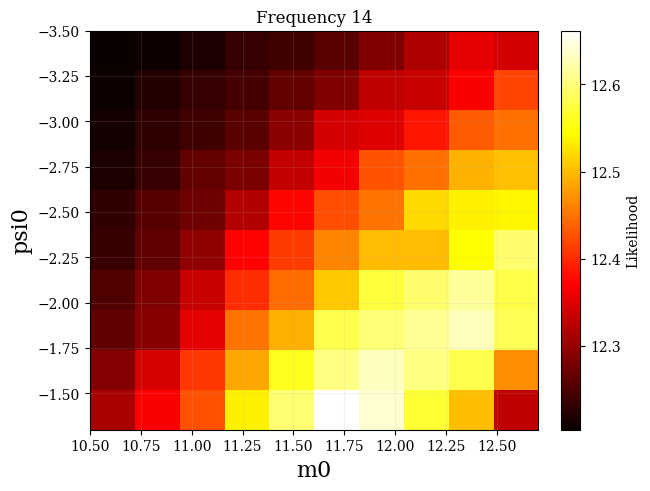

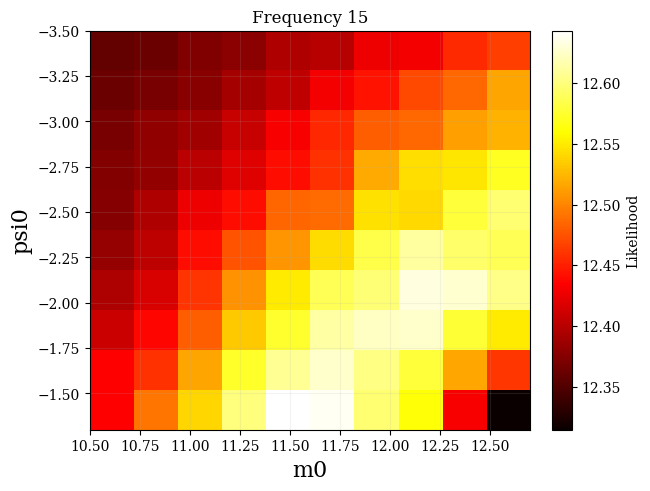

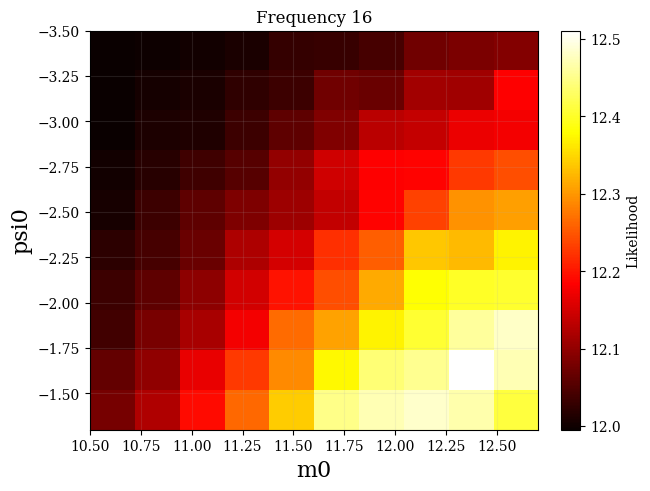

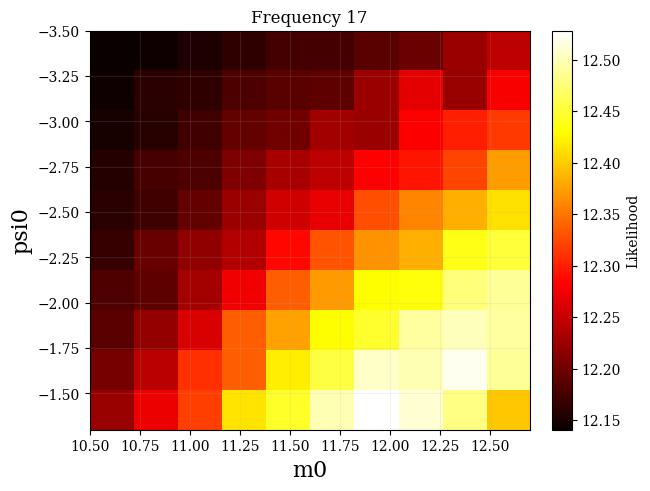

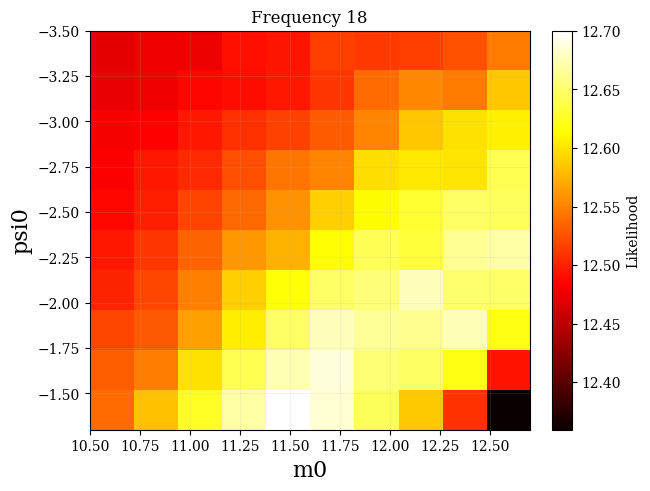

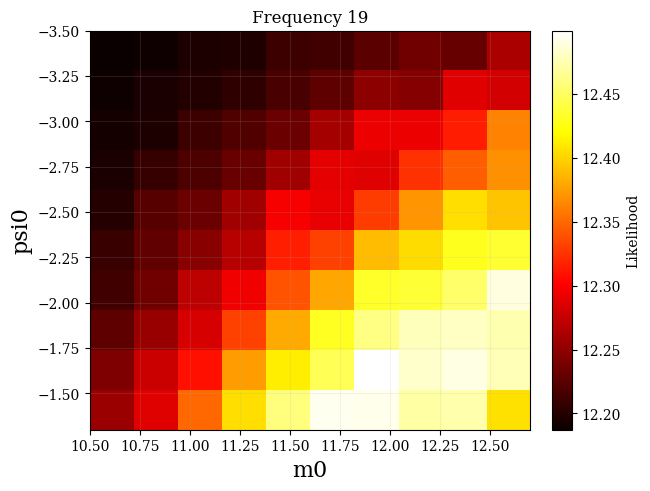

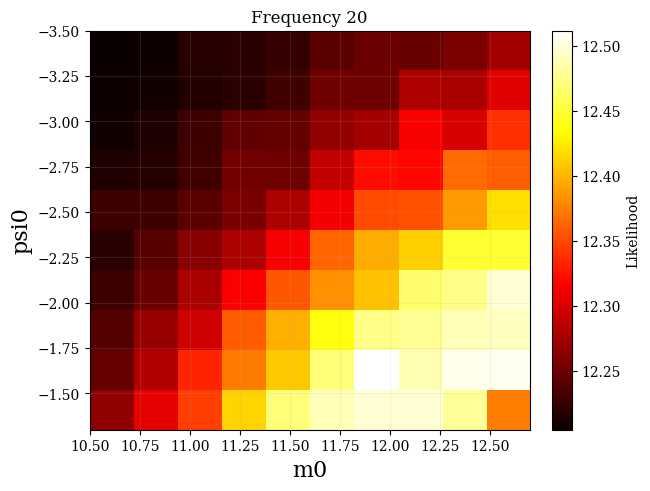

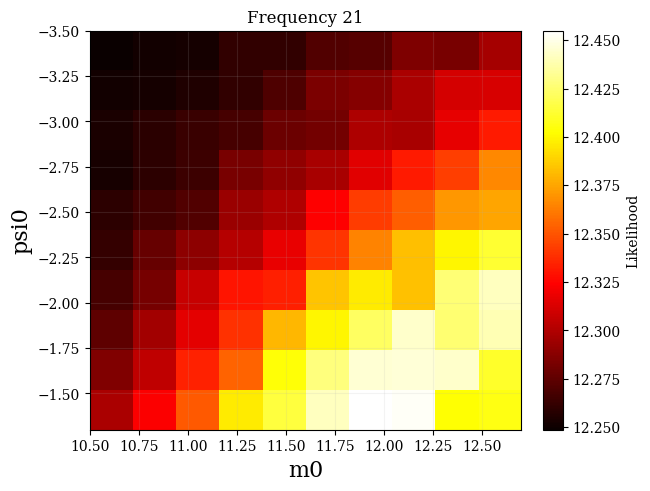

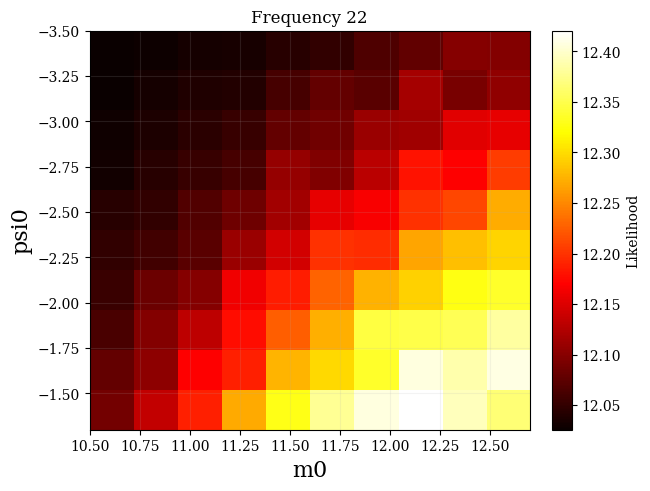

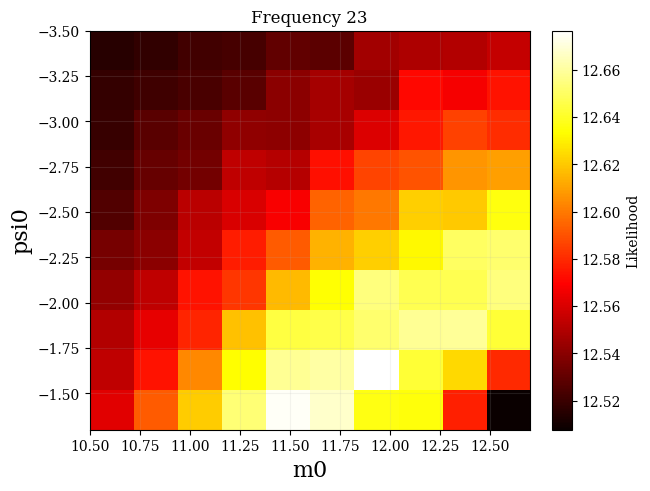

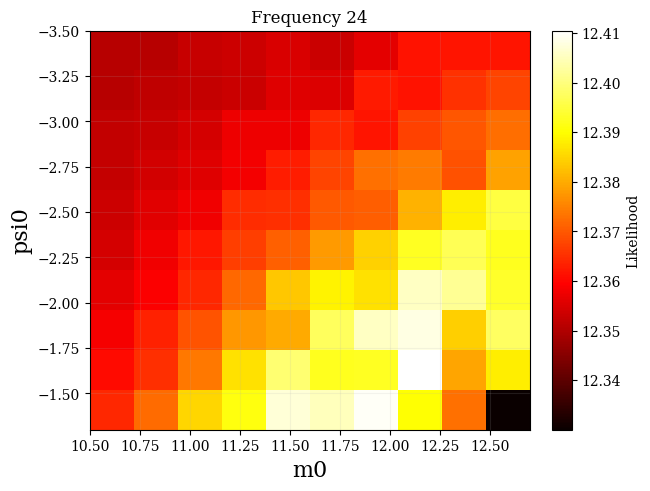

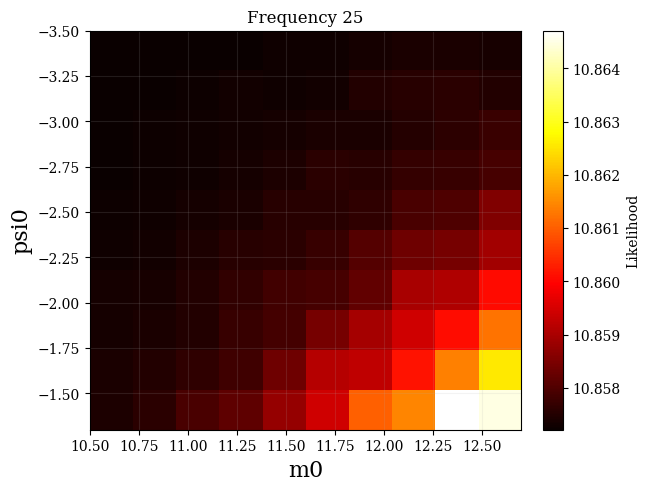

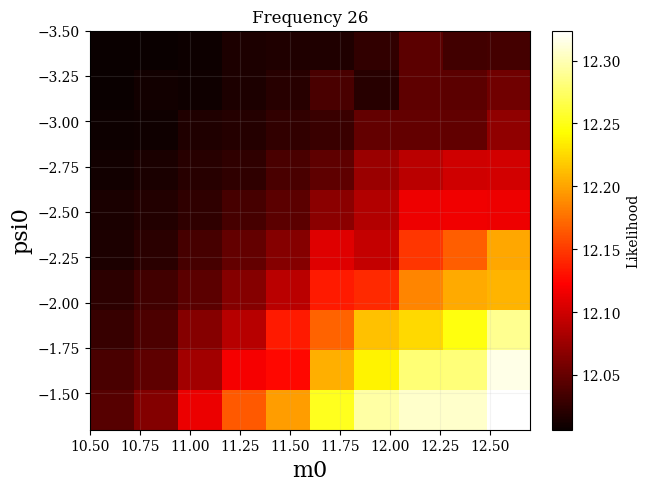

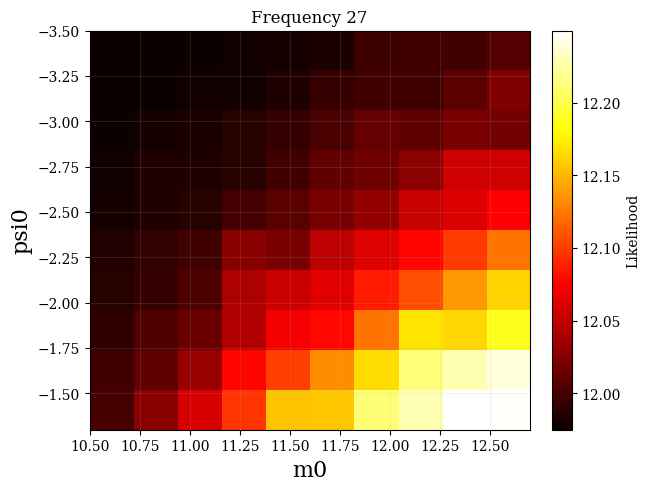

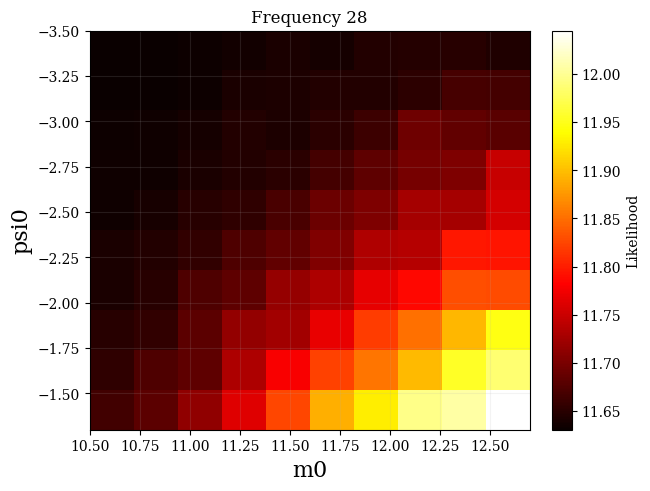

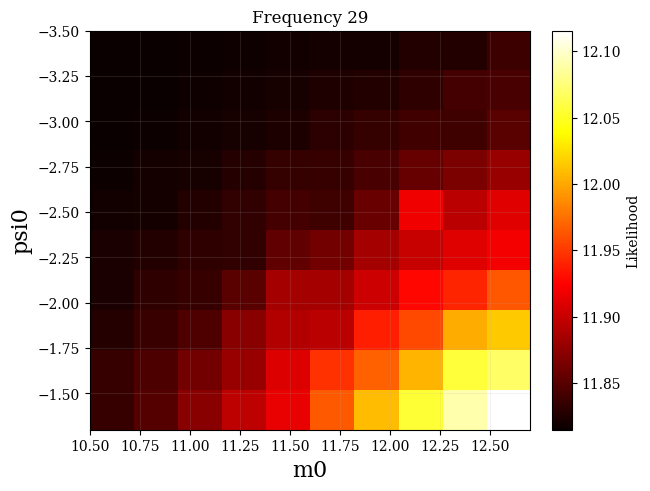

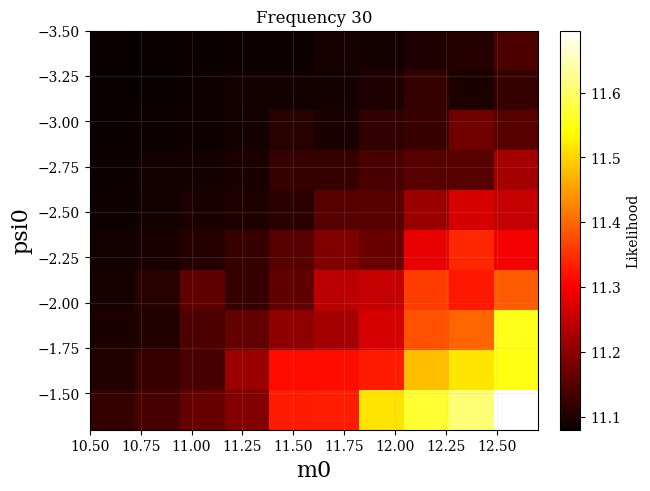

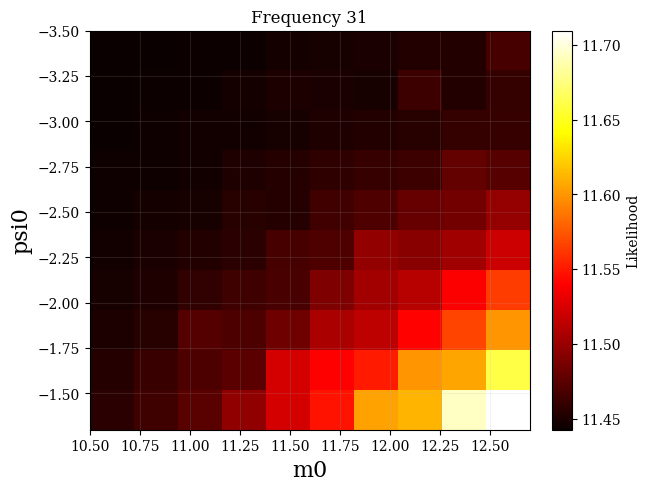

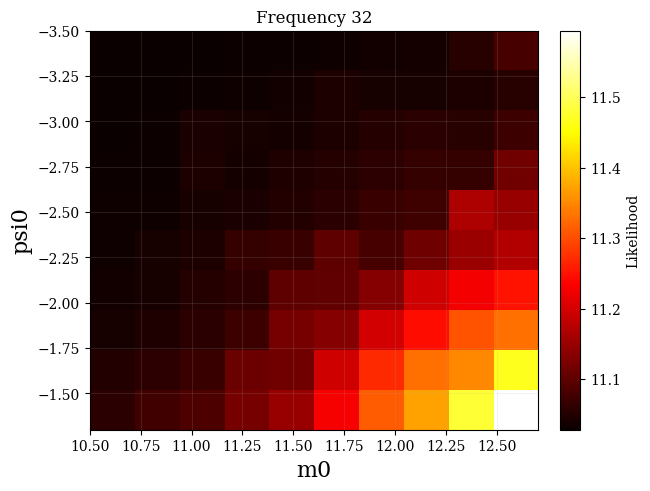

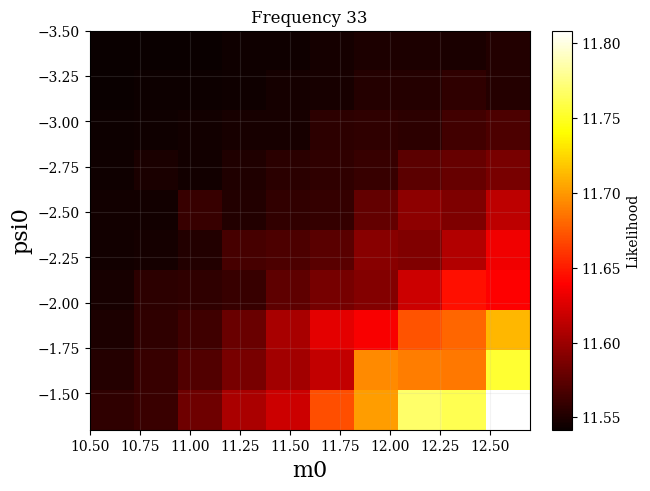

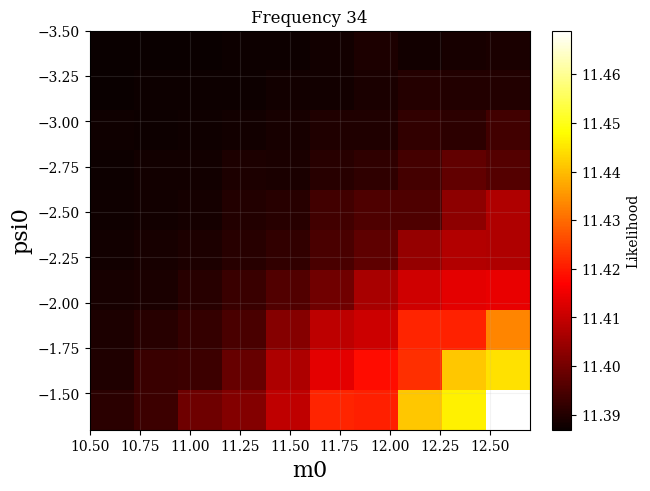

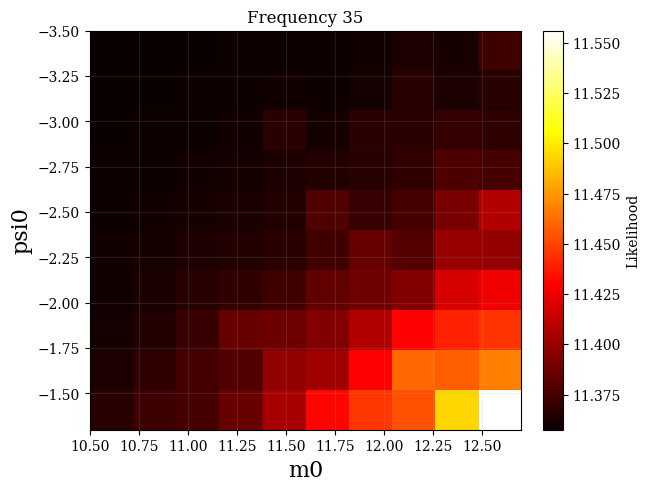

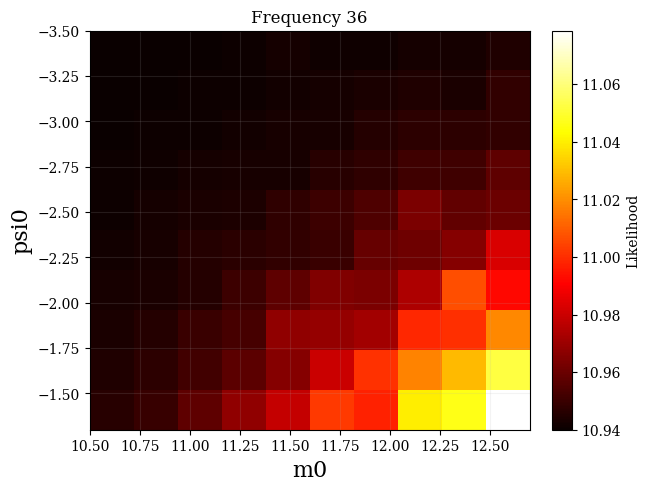

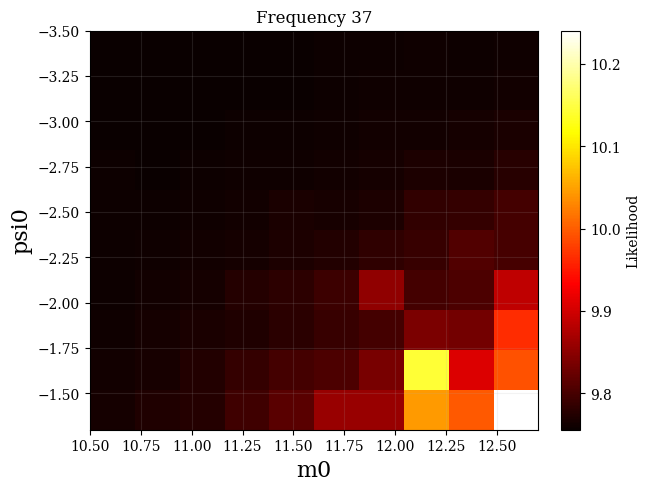

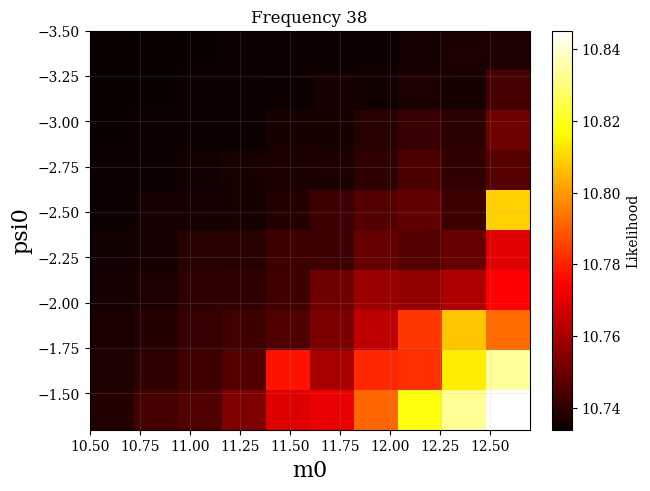

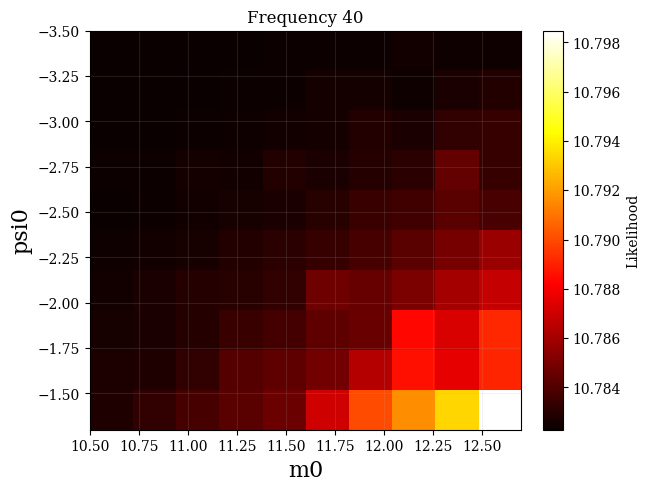

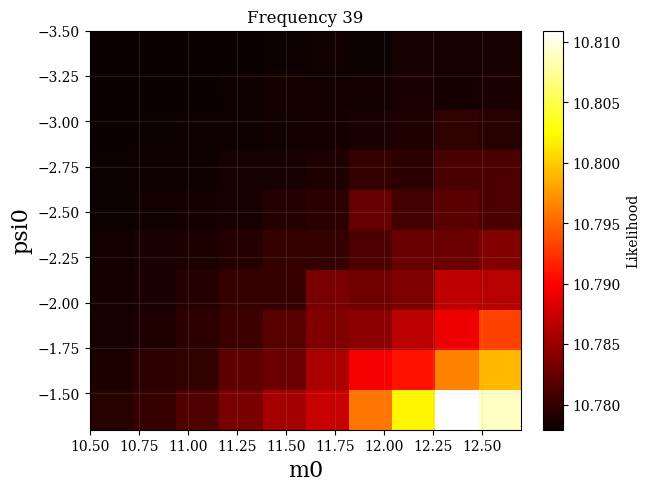

In [17]:
figsize=(16,4)
for i,v in enumerate(Likelihoods3):
    figs, ax = plt.subplots(layout='constrained')
    plt.title(f'Frequency {i+1}')
    plt.figure(i)
    im = ax.imshow(np.log10(v), cmap='hot', interpolation='nearest',extent = (list(DistObj.parameters)[1][0],list(DistObj.parameters)[1][-1],list(DistObj.parameters)[0][-1],list(DistObj.parameters)[0][0]), aspect = 'auto')
    ax.set_xlabel(DistObj.par_names[1],fontsize=16)
    ax.set_ylabel(DistObj.par_names[0],fontsize=16)
    figs.colorbar(im,label='Likelihood')